# Aggregate Functions :

### Notes:
```
AGGREGATE FUNCTIONS : Performs a calculation on a set of values across multiple rows and returns a single summary value
Fucntions: COUNT(), SUM(), MIN(), MAX(), AVG()
1. Takes input as multiple rows or a set of values and out in single row or a single value
2. Often used by GROUP BY, HAVING, ORDER BY clause
```

### Challenges

#### Find the following 
```
1. total number of orders, 
2. total sales of all orders
3. average sales of all orders
4. highest sale of all orders
5. lowest sales of all orders
6. categorised by customer id
```

In [32]:
%%sql
use MyDatabase;
select customer_id, count(*) as `Total Sales Count`,
    sum(sales) as `Total Sales`,
    round(avg(sales), 1) as `AVG Sales`,
    max(sales) as `Highest Sale Value`,
    min(sales) as `Lowest Sale Value`    
from orders group by customer_id;

Running query in 'mysql+pymysql://'

4 rows affected.

customer_id,Total Sales Count,Total Sales,AVG Sales,Highest Sale Value,Lowest Sale Value
1,1,35,35.0,35,35
2,1,15,15.0,15,15
3,1,20,20.0,20,20
6,1,10,10.0,10,10


#### Find the following 
```
1. total number of customers, 
2. total score of all customers
3. average score of all customers
4. highest score of all customers
5. lowest score of all customers
6. categorised by country
```

In [40]:
%%sql
select country, count(*) as `Total Number of Customers`,
    sum(score) as `Total Score`,
    round(avg(ifnull(score, 0))) as `AVG Score`,
    max(score) as `Highest Score`,
    min(score) as `Lowest Score`
from customers
group by country;

Running query in 'mysql+pymysql://'

3 rows affected.

country,Total Number of Customers,Total Score,AVG Score,Highest Score,Lowest Score
Germany,2,850,425,500,350
USA,2,900,450,900,0
UK,1,750,750,750,750


# Window basics : 

### Notes:
```
WINDOW FUNCTIONS : Perform calculations (e.g. aggregation) on specific subset of data, without losing the level of details of rows
Functions : 
    AGGREGATE       : COUNT(expr), SUM(expr), AVG(expr), MIN(expr), MAX(expr)
    ROWS            : OVER(), OVER(ORDER/PARTITION BY columnName)
    RANK            : ROW_NUMBER(), RANK(), DENSE_RANK(), CUME_DIST(), PERCENT_RANK(), NTILE(n)
    VALUE ANALYTICS : LEAD(expr, offset, default), LAG(expr, offset, default), FIRST_VALUE(expr)
```

### Challenges:

#### Find the following from SALESDB:
```
1. Total sales
2. Total sales by each product
3. Total sales by each product but also provide details such as orderid and orderdate
```

In [55]:
%%sql
use salesdb;
select orderid,
    orderdate,
    productid,
    sum(sales) OVER(PARTITION BY productid) as `Total Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,Total Sales
1,2025-01-01,101,140
3,2025-01-10,101,140
8,2025-02-18,101,140
9,2025-03-10,101,140
2,2025-01-05,102,105
7,2025-02-15,102,105
10,2025-03-15,102,105
5,2025-02-01,104,75
6,2025-02-05,104,75
4,2025-01-20,105,60


### PARTITION BY : Divide the entire results into partitions or category

In [103]:
%%sql
use salesdb;
select product,
    monthname(o.orderdate) as Month,
    sales
from products as p
    left join orders as o on p.productid = o.productid
ORDER BY case
        when o.orderdate is null then 1
        else 0
    end ASC,
    month(o.orderdate) ASC;

Running query in 'mysql+pymysql://'

11 rows affected.

product,Month,sales
Bottle,January,10
Bottle,January,20
Tire,January,15
Gloves,January,60
Bottle,February,90
Tire,February,30
Caps,February,25
Caps,February,50
Bottle,March,20
Tire,March,60


#### CHALLENGE : 

##### Without Partition BY : 

Find the total sales across all orders, additionally provide details such as order id and order date

In [109]:
%%sql
select orderid,
    productid,
    orderdate,
    sum(sales) over() as `Total Sales`
from orders
order by productid;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,orderdate,Total Sales
1,101,2025-01-01,380
3,101,2025-01-10,380
8,101,2025-02-18,380
9,101,2025-03-10,380
2,102,2025-01-05,380
7,102,2025-02-15,380
10,102,2025-03-15,380
5,104,2025-02-01,380
6,104,2025-02-05,380
4,105,2025-01-20,380


##### With Partition BY (Single Column): 

Find the total sales for each products, additionally provide details such as order id and order date

In [121]:
%%sql
select orderid,
    orderdate,
    productid, 
    sales,
    sum(sales) over(partition by productid) as `Total Sales By Product`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,sales,Total Sales By Product
1,2025-01-01,101,10,140
3,2025-01-10,101,20,140
8,2025-02-18,101,90,140
9,2025-03-10,101,20,140
2,2025-01-05,102,15,105
7,2025-02-15,102,30,105
10,2025-03-15,102,60,105
5,2025-02-01,104,25,75
6,2025-02-05,104,50,75
4,2025-01-20,105,60,60


Find the total sales for across all orders and for each products, additionally provide details such as order id and order date

In [120]:
%%sql
select orderid,
    orderdate,
    productid, 
    sales,
    sum(sales) over(partition by productid) as `Total Sales By Product`,
    sum(sales) over() as `Total Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,sales,Total Sales By Product,Total Sales
1,2025-01-01,101,10,140,380
3,2025-01-10,101,20,140,380
8,2025-02-18,101,90,140,380
9,2025-03-10,101,20,140,380
2,2025-01-05,102,15,105,380
7,2025-02-15,102,30,105,380
10,2025-03-15,102,60,105,380
5,2025-02-01,104,25,75,380
6,2025-02-05,104,50,75,380
4,2025-01-20,105,60,60,380


##### With Partition BY (Multi Column): 

```
Find the total sales 
                for across all orders and 
                for each products and 
                each combinations of product and order status,
        additionally provide details such as order id and order date
```

In [129]:
%%sql
select orderid,
    orderdate,
    productid,
    orderstatus,
    sales,
    sum(sales) over() as `Total Sales`,
    sum(sales) over(partition by productid) as `Total Sales By Product`,
    sum(sales) over(partition by productid, orderstatus) as `Total Sales By Product and Status`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,orderdate,productid,orderstatus,sales,Total Sales,Total Sales By Product,Total Sales By Product and Status
1,2025-01-01,101,Delivered,10,380,140,30
3,2025-01-10,101,Delivered,20,380,140,30
8,2025-02-18,101,Shipped,90,380,140,110
9,2025-03-10,101,Shipped,20,380,140,110
7,2025-02-15,102,Delivered,30,380,105,30
2,2025-01-05,102,Shipped,15,380,105,75
10,2025-03-15,102,Shipped,60,380,105,75
5,2025-02-01,104,Delivered,25,380,75,75
6,2025-02-05,104,Delivered,50,380,75,75
4,2025-01-20,105,Shipped,60,380,60,60


### ORDER BY : Use to sorth data within a window in eith ASC or DESC

##### Challenges :

Do the following from orders table:
1. Categorise by Month
2. RANK and Order by sales from highest to lowest
3. Additionally provide details such as Order id, product id, order date in format of 21st, Jun 2026

In [154]:
%%sql
select orderid,
    date_format(orderdate, '%D, %b %Y') as OrderDate,
    productid,
    Monthname(orderdate) as Month,
    Sales,
    RANK() over(
        partition by month(orderdate)
        order by sales desc
    ) as `Rank By Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,OrderDate,productid,Month,Sales,Rank By Sales
4,"20th, Jan 2025",105,January,60,1
3,"10th, Jan 2025",101,January,20,2
2,"5th, Jan 2025",102,January,15,3
1,"1st, Jan 2025",101,January,10,4
8,"18th, Feb 2025",101,February,90,1
6,"5th, Feb 2025",104,February,50,2
7,"15th, Feb 2025",102,February,30,3
5,"1st, Feb 2025",104,February,25,4
10,"15th, Mar 2025",102,March,60,1
9,"10th, Mar 2025",101,March,20,2


### FRAME or WINDOW FRAME : Use to define a subset of rows in each window that is relevent for calculation
```
And if in OVER() if order by is used then a default FRAME is always used as 'UNBOUNDED PRECEEDING' or 'ROWS BETWEEN CURRENT ROW AND UNBOUNDED PRECEEDING'
```

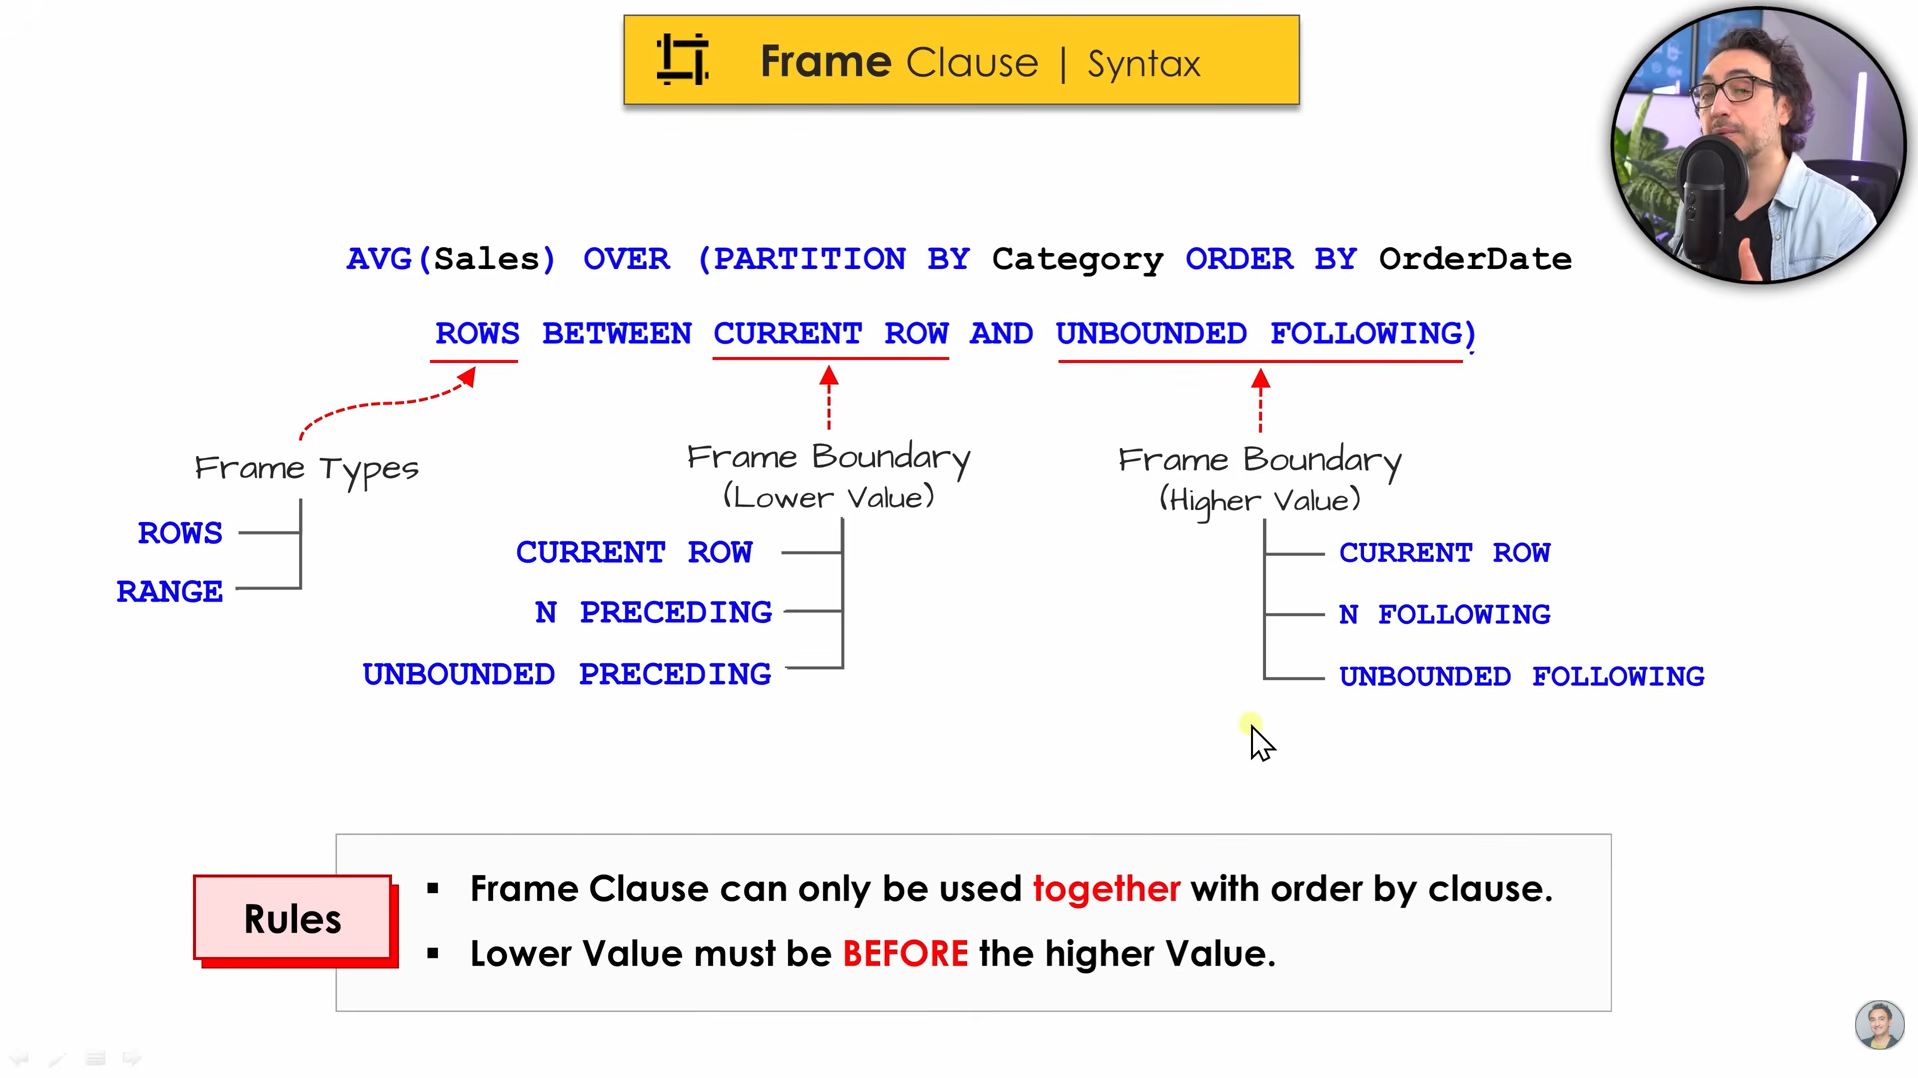

#### Challenges :

In [167]:
%%sql
select orderid,
    productid,
    monthname(orderdate) as `Month`,
    orderstatus,
    sales,
    sum(sales) over(
        partition by month(orderdate), orderstatus
        order by month(orderdate), orderstatus
        rows between current row and 2 following
    ) as `Total Sales`
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,Month,orderstatus,sales,Total Sales
1,101,January,Delivered,10,30
3,101,January,Delivered,20,20
2,102,January,Shipped,15,75
4,105,January,Shipped,60,60
5,104,February,Delivered,25,105
6,104,February,Delivered,50,80
7,102,February,Delivered,30,30
8,101,February,Shipped,90,90
9,101,March,Shipped,20,80
10,102,March,Shipped,60,60


### 4x RULES : 

#### RULES : 
1. WINDOW FUNCTION can be used only in select and order by clause.
2. WINDOW FUNCTION can not be used to filter the data.
3. Nesting of WINDOW FUNCTIONS NOT allowed
4. SQL executes WINDOW FUNCTIONS after WHERE clause.
5. WINDOW FUNCTIONS can be used together with GROUP BY in the same query , ONLY if the same columns are used.

#### WINDOW FUNCTIONS are executed after WHERE

##### Find out the total sales of product id 101 and 102 after categorising the orders on their status and rabk in high to low and additionally also provide, orderid, product id, date

In [190]:
%%sql
select orderid,
    productid,
    date_format(orderdate, '%D, %b-%y') as `orderdate`,
    monthname(orderdate) as `Month`,
    orderstatus,
    sum(sales) over(partition by month(orderdate)) as `Total Sales by Month`
from orders
where productid in (101, 102);

Running query in 'mysql+pymysql://'

7 rows affected.

orderid,productid,orderdate,Month,orderstatus,Total Sales by Month
1,101,"1st, Jan-25",January,Delivered,45
3,101,"10th, Jan-25",January,Delivered,45
2,102,"5th, Jan-25",January,Shipped,45
8,101,"18th, Feb-25",February,Shipped,120
7,102,"15th, Feb-25",February,Delivered,120
9,101,"10th, Mar-25",March,Shipped,80
10,102,"15th, Mar-25",March,Shipped,80


#### WINDOW Function used togesther with group by if columns are same

#### DO the following:
1. find out orderid, productid, order date, Month, order status, total sales by order status
2. rank by highest sales to lowest sales

In [187]:
%%sql
select orderid,
    productid,
    date_format(orderdate, '%D, %b-%y') as `orderdate`,
    date_format(orderdate, '%b') as `Month`,
    orderstatus,
    sum(sales) over(partition by month(orderdate), orderstatus) as `Total Sales by Order Date`,
    dense_rank() over(order by month(orderdate), orderstatus DESC) as 'RANK'
from orders;

Running query in 'mysql+pymysql://'

10 rows affected.

orderid,productid,orderdate,Month,orderstatus,Total Sales by Order Date,RANK
2,102,"5th, Jan-25",Jan,Shipped,75,1
4,105,"20th, Jan-25",Jan,Shipped,75,1
1,101,"1st, Jan-25",Jan,Delivered,30,2
3,101,"10th, Jan-25",Jan,Delivered,30,2
8,101,"18th, Feb-25",Feb,Shipped,90,3
5,104,"1st, Feb-25",Feb,Delivered,105,4
6,104,"5th, Feb-25",Feb,Delivered,105,4
7,102,"15th, Feb-25",Feb,Delivered,105,4
9,101,"10th, Mar-25",Mar,Shipped,80,5
10,102,"15th, Mar-25",Mar,Shipped,80,5


#### DO the following:
1. find out customer id, customer name, total sales by customers
2. rank by customer's highest sales to lowest sales

In [227]:
%%sql
select c.customerid,
    concat_ws(' ', c.firstname, c.lastname) as `Customer Name`,
    sum(ifnull(o.sales, 0)) as `Total Sales`,
    dense_rank() over(
        order by sum(ifnull(o.sales, 0)) desc
    ) as `Rank`
from customers as c
    left join orders as o on c.customerid = o.customerid
group by c.customerid;

Running query in 'mysql+pymysql://'

5 rows affected.

customerid,Customer Name,Total Sales,Rank
3,Mary,125,1
1,Jossef Goldberg,110,2
4,Mark Schwarz,90,3
2,Kevin Brown,55,4
5,Anna Adams,0,5


# Window Aggregate Functions : 

# Window Ranking Function : 

# Window Value Function : 

# Extra:

In [4]:
%%sql
use MyDatabase;

Running query in 'mysql+pymysql://'

++
||
++
++